# Method 3: Manual Assignment of Northern Districts (No adjacency constraint)

## Method Details:

#### Objective Function:

- Minimize the lack of compactness (a.k.a, the sum of distances between counties that are assigned to the same district).

#### Constraints:

1. Each county should be assigned to exactly one district.
2. The population in each district should be approximately equal (+- 20%) to the ideal district population size.

#### The 3 Large Population Counties Consideration
Given that there are three counties that contain very high population around Detroit, these districts will manuaglly be assigned to their own districts.

***Approach to this consideration***
1. **Adjust the Dataset**
- Remove the three large counties, Macomb, Oakland, and Wayne from the dataset, since they will manually be assigned to their own districts.
2. **Adjust the number of districts and recalculate the average distict population**
- Since we are removing the three largest counties, we will be to recalculate the average size we want our disticts to be based on the remaining counties.
3. **Modify and Re-run the Model**
- An additional modification I made when re-running this model, what I adjusted the district population constraint to be +/- 20%. This was the only way I was able to find an optimal solution.

#### Manual Assignment of Northern Most Counties into Districts

**Manual Assignment of District 11: (Most Northern Counties)**
1. Alger
2. Baraga
3. Chippewa
4. Delta
5. Dickinson
6. Gogebic
7. Houghton
8. Iton
9. Keweenaw
10. Luce
11. Mackinac
12. Marquette
13. Menominee
14. Ontonagan
15. Schoolcraft
- Total population: 301397

**Manual Assignment of District 10: (2nd Most Northwen Counties)**
1. Emmet
2. Cheboygan
3. Presque Isle
4. Charlevoix
5. Antrim
6. Otsego
7. Montomorency
8. Alpena
- Total population: 188066


### Step 1: Load necessary libraries

In [1]:
# Import necessary libraries
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt   
import pandas as pd 
from math import pi, pow, sin, cos, asin, sqrt, floor
from pulp import *

### Step 2: Read in the Excel file and GeoJSON file
- Then merge the two data sources to have a comprehensive dataset.
    - In the 'michigan_counties' dataframe, the county name column is 'county_names', and in the 'michigan_counties_geojson' datafram, the county name column is 'name'.

In [2]:
# Read in the Excel file of Michigan counties
xlsx_file_path = '/Users/stefanjenss/Desktop/DataScience/Decision_analytics/Module6/michigan_counties.xlsx'
michigan_counties = pd.read_excel(xlsx_file_path)

# Read in the GeoJSON file of Michigan county boundaries
geojson_file_path = '/Users/stefanjenss/Desktop/DataScience/Decision_analytics/Module6/michigan_counties.geojson'
michigan_counties_geojson = gpd.read_file(geojson_file_path)

print(michigan_counties.head())
print("")
print(michigan_counties_geojson.head())

   count_id county_names   latitude  longitude  pop2020
0         0     Leelanau  45.151771 -86.038496    22870
1         1      Clinton  42.943652 -84.601517    79748
2         2      Wexford  44.338367 -85.578414    34196
3         3       Branch  41.916119 -85.059044    44531
4         4        Ionia  42.945094 -85.074603    66809

                                    geo_point_2d statefp countyfp  countyns  \
0   {'lon': -86.0384960523, 'lat': 45.151770859}      26      089  01622987   
1  {'lon': -84.6015165533, 'lat': 42.9436523662}      26      037  01622961   
2  {'lon': -85.5784138137, 'lat': 44.3383668115}      26      165  01623023   
3  {'lon': -85.0590443604, 'lat': 41.9161186535}      26      023  01622954   
4  {'lon': -85.0746031181, 'lat': 42.9450938315}      26      067  01622976   

   geoid      name         namelsad stusab lsad classfp  ... cbsafp metdivfp  \
0  26089  Leelanau  Leelanau County     MI   06      H1  ...  45900     None   
1  26037   Clinton   Clinton

In [3]:
# Merge the two dataframes on the county name
michigan_counties_merged = michigan_counties.merge(michigan_counties_geojson, left_on='county_names', right_on='name', how='inner')
michigan_counties_merged.head()

,count_id,county_names,latitude,longitude,pop2020,geo_point_2d,statefp,countyfp,countyns,geoid,...,cbsafp,metdivfp,funcstat,aland,awater,intptlat,intptlon,state_name,countyfp_nozero,geometry
0,0,Leelanau,45.151771,-86.038496,22870,"{'lon': -86.0384960523, 'lat': 45.151770859}",26,089,01622987,26089,...,45900,None,A,899241895,5659105307,+45.1461816,-086.0515740,Michigan,89,"POLYGON ((-85.56175 44.95226, -85.56209 44.950..."
1,1,Clinton,42.943652,-84.601517,79748,"{'lon': -84.6015165533, 'lat': 42.9436523662}",26,037,01622961,26037,...,29620,None,A,1467017475,21098128,+42.9504550,-084.5916949,Michigan,37,"POLYGON ((-84.83762 43.03264, -84.83754 43.032..."
2,2,Wexford,44.338367,-85.578414,34196,"{'lon': -85.5784138137, 'lat': 44.3383668115}",26,165,01623023,26165,...,15620,None,A,1463148726,27182043,+44.3313751,-085.5700462,Michigan,165,"POLYGON ((-85.81909 44.42450, -85.81910 44.425..."
3,3,Branch,41.916119,-85.059044,44531,"{'lon': -85.0590443604, 'lat': 41.9161186535}",26,023,01622954,26023,...,17740,None,A,1311605515,34420092,+41.9184551,-085.0668852,Michigan,23,"POLYGON ((-85.29293 41.98482, -85.29293 41.984..."
4,4,Ionia,42.945094,-85.074603,66809,"{'lon': -85.0746031181, 'lat': 42.9450938315}",26,067,01622976,26067,...,24340,None,A,1479710906,22590318,+42.9446503,-085.0737660,Michigan,67,"POLYGON ((-85.07503 43.12021, -85.06470 43.120..."


### Step 3: Calculate the Distance Between County Pairs

In [4]:
# Define function to calculate distance between two sets of longitudes / latitudes

# Function to convert degrees to radians
def degrees_to_radians(x):
    return((pi / 180) * x)

# Function to calculate distance between two points on a sphere (in miles) given their longitudes and latitudes
def lon_lat_distance_miles(lon_a, lat_a, lon_b, lat_b):
    """
    Calculates the great-circle distance between two points on a sphere given their longitudes and latitudes.
    
    Parameters:
    lon_a (float): longitude of point A in degrees
    lat_a (float): latitude of point A in degrees
    lon_b (float): longitude of point B in degrees
    lat_b (float): latitude of point B in degrees
    
    Returns:
    float: distance between the two points in miles
    """
    radius_of_earth = 24872 / (2 * pi)
    c = sin((degrees_to_radians(lat_a) - \
    degrees_to_radians(lat_b)) / 2)**2 + \
    cos(degrees_to_radians(lat_a)) * \
    cos(degrees_to_radians(lat_b)) * \
    sin((degrees_to_radians(lon_a) - \
    degrees_to_radians(lon_b))/2)**2
    return(2 * radius_of_earth * (asin(sqrt(c))))

# Function to convert the distance between two points on a sphere (in miles) to meters
def lon_lat_distance_meters (lon_a, lat_a, lon_b, lat_b):
    return(lon_lat_distance_miles(lon_a, lat_a, lon_b, lat_b) * 1609.34)

In [5]:
# Remove population to allow easy joining of long and lat for each county pair
lat_lon = ['county_names', 'latitude', 'longitude']
lat_lon = michigan_counties_merged[lat_lon]

# Create list of county names for pairing        
county_names = michigan_counties['county_names'].to_numpy()

# Create each unique pair
pairs = []

# Loop through each county name and create a pair with each other county name
for i in range(len(county_names)):
    for j in range(i + 1, len(county_names)):
        pairs.append((county_names[i], county_names[j]))

# Create column names for county pairs df
col_names = ['county_1', 'county_2']

# Create df of county pairs                
county_pairs = pd.DataFrame(pairs, columns = col_names)

 # Add first county longitude and latitude
county_pairs = county_pairs.merge(lat_lon, left_on = 'county_1', right_on = 'county_names', how = 'left')
county_pairs.drop('county_names', axis = 1, inplace = True) # Drop county names column
county_pairs = county_pairs.rename(columns={'latitude': 'county_1_lat', 'longitude': 'county_1_long'}) # Rename columns

# Add second county longitude and latitude
county_pairs = county_pairs.merge(lat_lon, left_on = 'county_2', right_on = 'county_names', how = 'left')
county_pairs.drop('county_names', axis = 1, inplace = True) # Drop county names column
county_pairs = county_pairs.rename(columns={'latitude': 'county_2_lat', 'longitude': 'county_2_long'}) # Rename columns

# Add distance between each county pair in miles and meters;
distance_miles = [] # Create empty list to store distance in miles
distance_meters = [] # Create empty list to store distance in meters

# Loop through each county pair and calculate distance in miles and meters
for i in range(len(county_pairs)):
    distance_miles.append(lon_lat_distance_miles(county_pairs.iloc[i, 2], county_pairs.iloc[i, 3], county_pairs.iloc[i, 4], county_pairs.iloc[i, 5]))
    distance_meters.append(lon_lat_distance_meters(county_pairs.iloc[i, 2], county_pairs.iloc[i, 3], county_pairs.iloc[i, 4], county_pairs.iloc[i, 5]))

# Add distance columns to county pairs df
county_pairs['distance_miles'] = distance_miles
county_pairs['distance_meters'] = distance_meters

# Check table
county_pairs

,county_1,county_2,county_1_lat,county_1_long,county_2_lat,county_2_long,distance_miles,distance_meters
0,Leelanau,Clinton,45.151771,-86.038496,42.943652,-84.601517,100.038253,160995.562830
1,Leelanau,Wexford,45.151771,-86.038496,44.338367,-85.578414,32.050066,51579.452482
2,Leelanau,Branch,45.151771,-86.038496,41.916119,-85.059044,69.831366,112382.410744
3,Leelanau,Ionia,45.151771,-86.038496,42.945094,-85.074603,67.621439,108825.886417
4,Leelanau,Mecosta,45.151771,-86.038496,43.640768,-85.324634,49.938224,80367.581755
...,...,...,...,...,...,...,...,...
3398,Arenac,Alcona,44.042885,-83.747242,44.683623,-83.129008,43.010988,69219.303841
3399,Arenac,Livingston,44.042885,-83.747242,42.602917,-83.911528,15.593543,25095.312007
3400,Charlevoix,Alcona,45.502498,-85.373250,44.683623,-83.129008,155.151831,249692.047763
3401,Charlevoix,Livingston,45.502498,-85.373250,42.602917,-83.911528,102.674475,165238.138922


### Step 4: Modify the DataFrame to exclude the counties that will be manually assigned

4.1 Define the parameters for the problem

In [6]:
# Create a dictionary of county names and their populations
county_populations = michigan_counties_merged[['name', 'pop2020']].set_index('name').to_dict()['pop2020']

# Number of counties and districts in Michigan
n_counties = 83
n_districts = 14

4.2 Create lists of the large counties and the northern counites that will be manually assigned to a district

In [12]:
# Create a list of the three large counties
large_counties = ['Wayne', 'Oakland', 'Macomb']

# Create a list of the most northern counties
most_northern = ["Alger", "Baraga", "Chippewa", "Delta", "Dickinson", "Gogebic", "Houghton", "Iron", "Keweenaw", 
                 "Luce", "Mackinac", "Marquette", "Menominee", "Ontonagon", "Schoolcraft"]

# Create a list of the second most northern counties
second_most_northern = ["Emmet", "Cheboygan", "Presque Isle", "Charlevoix", "Antrim", "Otsego", 
                        "Montmorency", "Alpena"]

# Create a list of all the manually assigned counties
manual_counties = large_counties + most_northern + second_most_northern

# Create a new dataframe that doesn't contain any of the manual counties
michigan_counties_adjusted = michigan_counties_merged[~michigan_counties_merged['name'].isin(manual_counties)]


4.3 Adjust the number of counties and districts, and calculate the new ideal district population

In [48]:
# Adjust the number of counties and districts in Michigan
n_counties_adjusted = len(michigan_counties_adjusted)
n_districts_adjusted = n_districts - (len(large_counties) + 2)

# Approximate population of each district
average_district_population_adjusted = michigan_counties_adjusted['pop2020'].sum() / n_districts_adjusted

4.4 Filter the pairs to exclude the manual counties

In [49]:
# Filter the county pairs dataframe to only include counties that are not in the large counties list
county_pairs_adjusted = county_pairs[~county_pairs['county_1'].isin(manual_counties)]

# Create a dictionary of the adjusted county names and their populations
county_populations_adjusted = michigan_counties_adjusted[['name', 'pop2020']].set_index('name').to_dict()['pop2020']
county_names_adjusted = michigan_counties_adjusted['name'].to_numpy()

4.5 Create the optimization problem

In [53]:
# Initialize the adjusted model
model_adjusted = LpProblem("Michigan_Redistricting_Adjusted", LpMinimize)

# Decision variable: binary variable indicating whether a county is in a district
x_adjusted = LpVariable.dicts("x_adjusted", ((i, j) for i in county_names_adjusted for j in range(n_districts_adjusted)), cat='Binary')

# Objective Function: Minimize the total distance between counties in the same district
model_adjusted += lpSum(county_pairs_adjusted.iloc[i, 7] * x_adjusted[(county_pairs_adjusted.iloc[i, 0], j)] for i in range(len(county_pairs_adjusted)) for j in range(n_districts_adjusted))

# Constraints: Each county must be assigned to exactly one district
for i in range(len(county_names_adjusted)):
    model_adjusted += lpSum(x_adjusted[(county_names_adjusted[i], j)] for j in range(n_districts_adjusted)) == 1

# Constraints: Each district must have a population within 20% of the average population
for j in range(n_districts_adjusted):
    model_adjusted += lpSum(county_populations_adjusted[county_names_adjusted[i]] * x_adjusted[(county_names_adjusted[i], j)] for i in range(len(county_names_adjusted))) >= 0.80 * average_district_population_adjusted # Lower bound
    model_adjusted += lpSum(county_populations_adjusted[county_names_adjusted[i]] * x_adjusted[(county_names_adjusted[i], j)] for i in range(len(county_names_adjusted))) <= 1.20 * average_district_population_adjusted # Upper bound

4.6 Solve the model and print the results

In [54]:
# Solve the adjusted model
model_adjusted.solve()

# Print the status of the solution
print("Status:", LpStatus[model_adjusted.status])

# Print the objective function value
print("Objective Function Value:", value(model_adjusted.objective))
print("")

# Print the results by county name and district number, along with the total population in each district and the population of each county
for j in range(n_districts_adjusted):
    print("District", j + 1, ":")
    district_counties = [i for i in range(n_counties_adjusted) if x_adjusted[(county_names_adjusted[i], j)].varValue == 1]
    district_population = sum([county_populations_adjusted[county_names_adjusted[i]] for i in district_counties])
    print("Total Population:", district_population)
    for i in range(len(county_names_adjusted)):
        if x_adjusted[(county_names_adjusted[i], j)].varValue == 1:
            print(county_names_adjusted[i], "Population:", county_populations_adjusted[county_names_adjusted[i]])
    print("")

# Manually assign the most northern counties into district 10 (counties listed in 'most_northern' list)
# Show the total population of the district and the population of each county
print("District 10:")
district_population = sum([county_populations[county] for county in most_northern])
print("Total Population:", district_population)
for county in most_northern:
    print(county, "Population:", county_populations[county])
print("")

# Manually assign the second most northern counties into district 11 (counties listed in 'second_most_northern' list)
# Show the total population of the district and the population of each county
print("District 11:")
district_population = sum([county_populations[county] for county in second_most_northern])
print("Total Population:", district_population)
for county in second_most_northern:
    print(county, "Population:", county_populations[county])
print("")

# Manually assign the three large counties to their own districts
for county in large_counties:
    print("District", j + 4, ":")
    print(county, "Population:", county_populations[county])
    j += 1
    print("")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/stefanjenss/anaconda3/envs/MSDS460/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/t2/xw_g33n96rxfmq14n3dnpb6h0000gn/T/4b208e39dbe74c8fad2c9add3307c0e2-pulp.mps timeMode elapsed branch printingOptions all solution /var/folders/t2/xw_g33n96rxfmq14n3dnpb6h0000gn/T/4b208e39dbe74c8fad2c9add3307c0e2-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 80 COLUMNS
At line 3150 RHS
At line 3226 BOUNDS
At line 3740 ENDATA
Problem MODEL has 75 rows, 513 columns and 1539 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 3.86173e+08 - 0.00 seconds
Cgl0005I 57 SOS with 513 members
Cgl0004I processed model has 66 rows, 513 columns (513 integer (513 of which binary)) and 1026 elements
Cbc0038I Initial state - 12 integers unsatisfied sum - 2.09401
Cbc0038I Pass   1: suminf.    0.176

### Step 5: Visualize the generated districts from the optimization results to get a better understanding of the country partitioning amount districts

In [55]:
michigan_counties_method3 = michigan_counties_merged.copy()

# Add a district assignment column to the dataframe
michigan_counties_method3['district'] = np.nan

# Assign the district number based on the optimization results
for j in range(n_districts_adjusted):
    district_counties = [i for i in range(n_counties_adjusted) if x_adjusted[(county_names_adjusted[i], j)].varValue == 1]
    for i in district_counties:
        michigan_counties_method3.loc[michigan_counties_method3['name'] == county_names_adjusted[i], 'district'] = j + 1

# Manually assign the most northern counties to district 11
for county in most_northern:
    michigan_counties_method3.loc[michigan_counties_method3['name'] == county, 'district'] = 11

# Manually assign the second most northern counties to district 12
for county in second_most_northern:
    michigan_counties_method3.loc[michigan_counties_method3['name'] == county, 'district'] = 12

# Assign the large counties to their own districts starting at district 12
for county in large_counties:
    michigan_counties_method3.loc[michigan_counties_method3['name'] == county, 'district'] = j + 2
    j += 1

# Convert the district column to an integer
michigan_counties_method3['district'] = michigan_counties_method3['district'].astype(int)

# Show the results
michigan_counties_method3[['name', 'district']]


,name,district
0,Leelanau,9
1,Clinton,7
2,Wexford,5
3,Branch,1
4,Ionia,1
...,...,...
78,Lapeer,6
79,Arenac,6
80,Charlevoix,12
81,Alcona,2


5.2 Plot the results

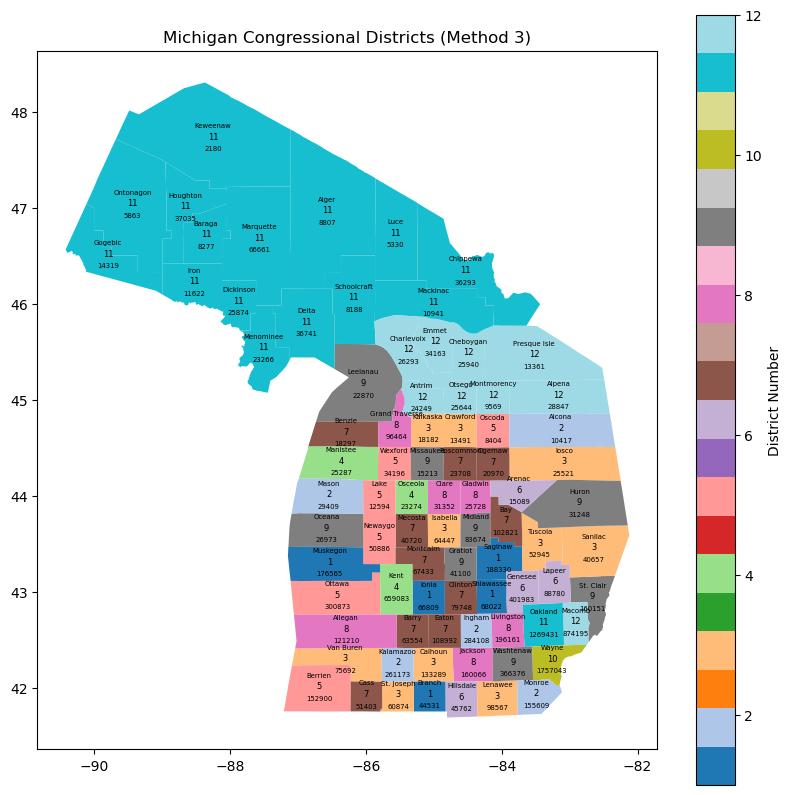

In [66]:
# Convert the 'geometry' column to a GeoSeries and create a GeoDataFrame
geo_michigan_counties_method3 = gpd.GeoDataFrame(michigan_counties_method3, geometry=gpd.GeoSeries(michigan_counties_method3['geometry']))

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
geo_michigan_counties_method3.plot(column='district', ax=ax, legend=True, cmap='tab20', legend_kwds={'label': "District Number"})
ax.set_title('Michigan Congressional Districts (Method 3)')

# Annotate each county with its assigned district number
for index, row in geo_michigan_counties_method3.iterrows():
    plt.annotate(text=row['district'], xy=(row['geometry'].centroid.x, row['geometry'].centroid.y), horizontalalignment='center', fontsize=6)

# Annotate each country with its name
for index, row in geo_michigan_counties_method3.iterrows():
    plt.annotate(text=row['name'], xy=(row['geometry'].centroid.x, row['geometry'].centroid.y+.12), horizontalalignment='center', fontsize=5)

# Annotate each county with its population
for index, row in geo_michigan_counties_method3.iterrows():
    plt.annotate(text=row['pop2020'], xy=(row['geometry'].centroid.x, row['geometry'].centroid.y-.12), horizontalalignment='center', fontsize=5)

# Show the plot
plt.show()
